In [1]:
# ======================================================================================
#  Imports
# ======================================================================================

import asymmetree.treeevolve as te
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import copy
import seaborn as sns
import pandas as pd

from bmg_Tony import bmg
from bmg_fun import convert_to_nx
from insert_hybrid import insertHybrid
from BICcherry import BICcherry
from BICcherryRestrict import BICcherryRestrict
from BCEA import BCEA
from BCEA_multilayered import MLBCEA

# ======================================================================================
#  Baumgenerierung - generiert einen zufälligen Genbaum
# ======================================================================================

def generateGeneTree(nSpecies: int, max_leaves: int):

    while True:

        # species tree
        speciesTree = te.species_tree_n_age(
            age = 1.0,
            n = nSpecies
            #, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
        )
        # gene tree
        T = te.dated_gene_tree(
            speciesTree, dupl_rate=1.0, loss_rate=0, hgt_rate=0.2, gc_rate=0.2, prohibit_extinction="per_species", dupl_polytomy=0.5
        )
        # prune all loss branches and the planted root
        geneTree = te.prune_losses(T)

        nLeaves = len(list(geneTree.leaves()))
        if nLeaves < max_leaves and nLeaves > 2:  #wenn es nur zwei Blätter (oder nSpezies?????) gibt, so lassen sich keine Hybriden einfügen
            break

    Tree = convert_to_nx(geneTree)

    return Tree, nLeaves

# ======================================================================================
#  Check BCBMG
# ======================================================================================
def check_BCBMG(Network :nx.DiGraph, mode :str, model :str) ->bool:
    BMG = bmg(Network,mode)

    if model == "BC":
        BC = BICcherry(BMG)
    elif model == "BCR" :
        BC = BICcherryRestrict(BMG)
    elif model == "BCEA":
        BC = BCEA(BMG,mode)
    elif model == "MLBCEA":
        BC,_,_ = MLBCEA(BMG)
    else:
        raise ValueError("Kein gültiges Model als Input")

    BCBMG = bmg(BC, mode)

    return nx.utils.graphs_equal(BMG,BCBMG)

# ======================================================================================
#  Ein Run: Hybride einfügen bis der BCEA scheitert
# ======================================================================================
def insert_hybrid_till_break(Tree :nx.DiGraph, max_hybrids :int, mode :str, model :str) ->int:

    insertedHybrids = 0

    Network = Tree.copy()

    while check_BCBMG(Network, mode, model) and insertedHybrids < max_hybrids:

        Network = insertHybrid(Network)
        insertedHybrids += 1

    censored = insertedHybrids >= max_hybrids
    
    return insertedHybrids, censored  



# ======================================================================================
#  simulation function
# ======================================================================================      

def run_simulation(species_range, max_leaves :int, trees_per_nLeaves :int, n_runs :int, max_hybrids :int, seed: int = None):

    if seed:
        random.seed(seed)
        np.random.seed(seed)

    job_matrix = np.zeros((max_leaves + 1,len(species_range))) 

    for i in range(max_leaves + 1):
        for j,nSpecies in enumerate(species_range):

            if i > 2 and i > nSpecies -1:
                job_matrix[i][j] = trees_per_nLeaves
    # print(sum(job_matrix[:,3]))
    # print(job_matrix)

    hybrid_matrix = np.zeros((max_leaves + 1,len(species_range)))
    censored_matrix = np.zeros((max_leaves + 1,len(species_range)))


    for row_idy, nSpecies in enumerate(species_range):       # durch alle nSpezies iterieren
        while job_matrix[:,row_idy].sum() > 0:               # solange noch Einträge in der job_id sind
            insertedHybrids = 0
            censored_runs = 0
            Tree, nLeaves = generateGeneTree(nSpecies=nSpecies, max_leaves=max_leaves + 1)

            if job_matrix[nLeaves][row_idy] > 0:

                for run in range(n_runs):

                    k, censored = insert_hybrid_till_break(Tree, max_hybrids=max_hybrids, mode=MODE, model = MODEL)
                    insertedHybrids += k
                    censored_runs += int(censored)

                hybrid_matrix[nLeaves,row_idy] += insertedHybrids / n_runs
                censored_matrix[nLeaves, row_idy] += censored_runs / n_runs   # Anteil der Runs, die das Cap erreicht haben
                job_matrix[nLeaves,row_idy] -= 1

            print(sum(sum(job_matrix)))

    hybrid_matrix /= trees_per_nLeaves

    return hybrid_matrix,censored_matrix

In [2]:
# ======================================================================================
#  Konfiguration
# ======================================================================================

random.seed(0)
np.random.seed(0)

MODE = "strong"
MODEL = "BCEA"   #Entweder BC oder BCR oder BCEA oder MLBCEA

species_range: tuple = tuple(range(2, 8))    # Anzahl Spezies im Genbaum
max_leaves: int = 15                         # Obergrenze Blätter (Rechenaufwand)
trees_per_nLeaves = 5                        # Anzahl Genbäume je Kombination aus Spezieszahl und Blattzahl
n_runs: int = 20                             # Runs (Hybrid-Sequenzen) pro Baum
max_hybrids: int = 99                        # Sicherheitsgrenze pro Run

hybrid_matrix,censored_matrix = run_simulation(species_range,max_leaves,trees_per_nLeaves,n_runs,max_hybrids,seed = 0)

339.0
338.0
337.0
336.0
335.0
334.0
333.0
332.0
331.0
330.0
329.0
328.0
327.0
326.0
325.0
324.0
323.0
322.0
321.0
320.0
320.0
319.0
318.0
317.0
316.0
315.0
314.0
313.0
312.0
311.0
310.0
309.0
309.0
308.0
307.0
307.0
306.0
305.0
304.0
303.0
302.0
302.0
301.0
300.0
299.0
299.0
298.0
298.0
297.0
296.0
296.0
296.0
295.0
294.0
294.0
294.0
293.0
293.0
293.0
293.0
293.0
293.0
293.0
292.0
291.0
291.0
291.0
290.0
290.0
290.0
289.0
288.0
287.0
287.0
286.0
286.0
286.0
286.0
285.0
285.0
285.0
284.0
284.0
284.0
284.0
284.0
284.0
283.0
283.0
283.0
282.0
282.0
282.0
282.0
282.0
282.0
282.0
281.0
281.0
281.0
281.0
281.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
280.0
279.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
278.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
277.0
276.0
276.

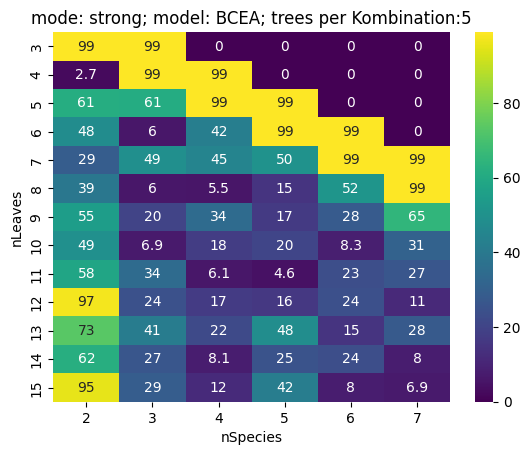

In [3]:
# ======================================================================================
#  Plot
# ======================================================================================

# Matrix-Slicing: Zeilen 0,1 und 2 uninteressant da nur Bäume mit mindestens 3 leaves Sinn machen
matrix_sliced = hybrid_matrix[3:, :]
y_labels = range(3, hybrid_matrix.shape[0])


sns.heatmap(matrix_sliced, 
            annot=True, 
            cmap="viridis", 
            xticklabels=list(species_range), 
            yticklabels=list(y_labels))
plt.xlabel("nSpecies")
plt.ylabel("nLeaves")
plt.title(f"mode: {MODE}; model: {MODEL}; trees per Kombination:{trees_per_nLeaves}")
plt.show()